# Laboratory 1 - From Pixels to Semantics
## Exercise 1: Exploratory Data Analysis
**Author:** Edoardo Canti<br>
<br>
**Notebook goal:** This notebook is used in order to perform Exploratory Data Analysis on both **training** and **test** set of GTSRB dataset.
Hopefully, this analysis will help identify insights from the data that are not immediately apparent, which could potentially guide the development of future exercises.

### Notes
- **Personal thoughts and comments**: during the drafting process of the notebook, will be provided markdowns regarding personal thoughts, ideas or general comments about the projetc design. I think this will be helpful both for me and for who reads (as this will somehow work as "documentation")

- **Notation**: if during the drafting process some details are considered more important than others, in order to evaluate results or to make additional consideration, those will be marked with [TBC.num] (To Be Considered), where num indicates the "identifier" for the final considerations. However I'll try to answer or provide further explainations of all personal thoughts and comments.

- **Use of LLMs**: If AI tools are used for programming, the following information will be provided: which model was used, what question was asked, and whether the model’s response was modified (if not specified, this means the model’s original response was used).

- **Analysis**: personal thoughts and comments are intended as **Analysis**, but since those will be sparsed in the notebook I will summarize them together in a dedicated section at the end of the notebook.

In [ ]:
# Standard imports and aliases.
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
import torchvision.transforms.v2 as T     # Use transforms v2; much more efficient.
from torchvision.datasets import GTSRB
import matplotlib.pyplot as plt

# Your code here.
transform = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
training_data = GTSRB('_data/', split = "train", transform=transform, download=True)
print(type(training_data))

<class 'torchvision.datasets.gtsrb.GTSRB'>


### About the dataset organization
- By reading the **GTRSB/Training/readme.txt** it is clear that data are organized in subdirectories such that **each subdirectory** collects data for a **single class**. 
- Given a total of 43 subdirectories we can conclude that there are 43 different classes.
- for each of the aforementioned subdirectory exists a csv file with metadata.

In [2]:
# I'd like to take a look at one of them for starting...
train_df = pd.read_csv("_data/gtsrb/GTSRB/Training/00000/GT-00000.csv", sep=";")
train_df

,Filename,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId
0,00000_00000.ppm,29,30,5,6,24,25,0
1,00000_00001.ppm,30,30,5,5,25,25,0
2,00000_00002.ppm,30,30,5,5,25,25,0
3,00000_00003.ppm,31,31,5,5,26,26,0
4,00000_00004.ppm,30,32,5,6,25,26,0
...,...,...,...,...,...,...,...,...
145,00004_00025.ppm,86,93,7,8,78,84,0
146,00004_00026.ppm,90,96,8,9,82,88,0
147,00004_00027.ppm,95,100,9,9,87,92,0
148,00004_00028.ppm,98,106,8,10,90,97,0


- Now I see that these files contains infos about shapes.
- I would like to check if all images have the same, or at least, similar shapes in order to identify possibles outliers that could lead to a future results misinterpretations.
- but *before I want to do some more basic EDA...*

# 1) Basic EDA
Before investigating images shapes I'd like to take a look at the composition of the dataset. <br>
Especially I'm interested in:
- understanding if both **sets** are **balanced** or **not** 
- since data are a priori collected as training and test, understanding if classes are represented **accordingly** in training and test set (otherwise evaluate if using an alternative stratified sampling)

In [ ]:
# BASIC EDA ON TRAINING SET
PATH_PREFIX = "_data/gtsrb/GTSRB/Training/" # path to all possible subdirectories
GT_NAME_TEMPLATE = "GT-" # every csv file has this name form
import os
# Listing the content of PATH_PREFIX
print(os.listdir(PATH_PREFIX))
# Creating a list of string with the subdirs names (removing the only file with "." in the name)
dirs = [dirname for dirname in os.listdir(PATH_PREFIX) if "." not in dirname]
print(dirs)
dirs = sorted(dirs)
print("sorted directories names: {}".format(dirs)) # sorting

# Now dirs contains all the strings that will be appended to PATH_PREFIX in order to get the csv
def build_dataframe_from_csv(dirname: str) -> pd.DataFrame:
    df = None
    try:
        df = pd.read_csv(os.path.join(PATH_PREFIX, dirname ,GT_NAME_TEMPLATE+dirname+".csv"), sep = ";")
    except Exception as e:
        print("[ERROR] Error trying to load csv at {} because of {}".format(dirname,e))
    return df

# I'm going to collect each df in a list
# so that it will be easy to access descriptive stats itertively
all_dataframes = list()
for dirname in dirs:
    df = build_dataframe_from_csv(dirname)
    all_dataframes.append(df)
 
# print(all_dataframes) # removed to avoid notebook spam

['00031', '00009', '00036', '00000', '00038', '00007', '00039', '00006', '00001', '00008', '00037', '00030', '00041', '00012', '00015', '00023', '00024', '00040', '00025', '00022', '00014', '00013', '00035', '00032', '00004', '00003', '00002', '00005', '00033', '00034', 'Readme.txt', '00016', '00029', '00011', '00027', '00018', '00020', '00042', '00021', '00026', '00019', '00010', '00017', '00028']
['00031', '00009', '00036', '00000', '00038', '00007', '00039', '00006', '00001', '00008', '00037', '00030', '00041', '00012', '00015', '00023', '00024', '00040', '00025', '00022', '00014', '00013', '00035', '00032', '00004', '00003', '00002', '00005', '00033', '00034', '00016', '00029', '00011', '00027', '00018', '00020', '00042', '00021', '00026', '00019', '00010', '00017', '00028']
sorted directories names: ['00000', '00001', '00002', '00003', '00004', '00005', '00006', '00007', '00008', '00009', '00010', '00011', '00012', '00013', '00014', '00015', '00016', '00017', '00018', '00019', '00

## 1.1) Evaluating classes balanceness in Training Set

{0: 150, 1: 1500, 2: 1500, 3: 960, 4: 1320, 5: 1260, 6: 300, 7: 960, 8: 960, 9: 990, 10: 1350, 11: 900, 12: 1410, 13: 1440, 14: 540, 15: 420, 16: 300, 17: 750, 18: 810, 19: 150, 20: 240, 21: 240, 22: 270, 23: 360, 24: 180, 25: 1020, 26: 420, 27: 180, 28: 360, 29: 180, 30: 300, 31: 540, 32: 180, 33: 480, 34: 300, 35: 810, 36: 270, 37: 150, 38: 1380, 39: 210, 40: 240, 41: 180, 42: 180}


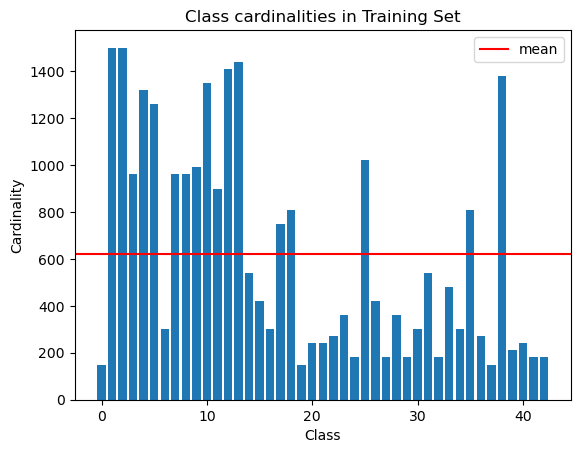

Mean number of elements in class: 619.5348837209302


In [4]:
# ARE CLASSES BALANCED?

# since a single df contains infos about a single class I'm going to count the
# number of elements in each df.
# I will return a dict {<df_index>:<cardinality>}
# Since I'm passing the ordered list, it will be easy to trace back the relative class
def get_class_cardinality(list_of_dfs: list[pd.DataFrame]) -> dict:
    classes_card_dict = dict()
    for item_idx in range(len(list_of_dfs)):
        cardinality = list_of_dfs[item_idx].shape[0]
        classes_card_dict[item_idx] = cardinality
    return classes_card_dict

class_cardinalities = get_class_cardinality(all_dataframes)
print(class_cardinalities)

plt.bar(list(class_cardinalities.keys()), list(class_cardinalities.values()))
plt.title("Class cardinalities in Training Set")
plt.xlabel('Class')
plt.ylabel('Cardinality')
plt.axhline(np.mean(list(class_cardinalities.values())), color='r', label="mean")
plt.legend()
plt.show()
print("Mean number of elements in class: {}".format(np.mean(list(class_cardinalities.values()))))

### LLM USED HERE!
**Reason:** I'd like to visualize classes cardinalities in ascending order, but I never remember how to sort a python dictionary by values keeping the key attached to it (I did it more then once, but never remember...) <br>
**Model:** Gemini<br>
### Asked to Gemini the following question:
**Question:**
Gemini se ho un python dict come questo:
{0: 150, 1: 1500, 2: 1500, 3: 960, 4: 1320, 5: 1260, 6: 300, 7: 960, 8: 960, 9: 990, 10: 1350, 11: 900, 12: 1410, 13: 1440, 14: 540, 15: 420, 16: 300, 17: 750, 18: 810, 19: 150, 20: 240, 21: 240, 22: 270, 23: 360, 24: 180, 25: 1020, 26: 420, 27: 180, 28: 360, 29: 180, 30: 300, 31: 540, 32: 180, 33: 480, 34: 300, 35: 810, 36: 270, 37: 150, 38: 1380, 39: 210, 40: 240, 41: 180, 42: 180}

che prende il nome di class_cardinalities, ritornato da questa funzione:
def get_class_cardinality(list_of_dfs: list[pd.DataFrame]) -> dict:
    classes_card_dict = dict()
    for item_idx in range(len(list_of_dfs)):
        cardinality = list_of_dfs[item_idx].shape[0]
        classes_card_dict[item_idx] = cardinality
    return classes_card_dict

come posso ordinarlo in modo crescente per values?


{0: 150, 19: 150, 37: 150, 24: 180, 27: 180, 29: 180, 32: 180, 41: 180, 42: 180, 39: 210, 20: 240, 21: 240, 40: 240, 22: 270, 36: 270, 6: 300, 16: 300, 30: 300, 34: 300, 23: 360, 28: 360, 15: 420, 26: 420, 33: 480, 14: 540, 31: 540, 17: 750, 18: 810, 35: 810, 11: 900, 3: 960, 7: 960, 8: 960, 9: 990, 25: 1020, 5: 1260, 4: 1320, 10: 1350, 38: 1380, 12: 1410, 13: 1440, 1: 1500, 2: 1500}


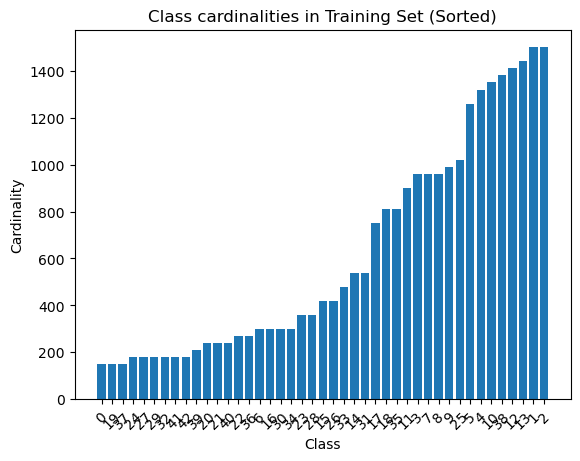

In [5]:
# Identifying less and most represented classed 
sorted_cardinalities = dict(sorted(class_cardinalities.items(), key=lambda item: item[1]))
print(sorted_cardinalities)
keys = [str(k) for k in sorted_cardinalities.keys()]
values = list(sorted_cardinalities.values())
plt.bar(keys, values)
plt.title("Class cardinalities in Training Set (Sorted)")
plt.xlabel('Class')
plt.ylabel('Cardinality')
plt.xticks(rotation=45)
plt.show()

**[TBC.1]** 
Personally I think we could identify at least 3 macro-groups *in the training set*:
- classes 5, 4, 10, 38 12, 13, 1, 2 as **Highly Represented Classes**
- classes 17, 18, 35, 11, 3, 7, 8, 9, 25 as **Medium Represented Classes**
- remaining as **low represented classes** <br>

(Alternatively **low represented classes** could be splitted into another group containing 15, 26, 33, 14, 31)

**Training set cannot be considered "too" imbalanced**<br>
The **Imbalanced Ratio (IR)** is defined as <br>  IR := cardinality_most_pupulated / cardinality_less_populated <br>

Since this ratio is exactly 10 in the training data, I don't think it could be considered a fully imbalanced dataset. <br>

My idea (**for the moment**) is to keep using the training data as provided, but keeping in mind that some classes are less common in the training set, so it will introduce a bias during the model training (and consequently during model inference). <br>

Eventually I think that a good practice would be to merge the less represented classes into one, but of course it depends on the type of problem (and data) we are trying to solve. For what I've seen until now I think I should just move on and doing the same evaluation on the **test set**.<br>

After this I will try to check if the distributions of classes **between both sets** are coherent.

## 1.2) Evaluating class balanceness in Test Set

In [6]:
# same with testing
transform = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
test_data = GTSRB('_data/', split = "test", transform=transform, download=True)
print(type(test_data))

<class 'torchvision.datasets.gtsrb.GTSRB'>


In [7]:
test_df = pd.read_csv("_data/gtsrb/GT-final_test.csv", sep=";")
test_df

,Filename,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId
0,00000.ppm,53,54,6,5,48,49,16
1,00001.ppm,42,45,5,5,36,40,1
2,00002.ppm,48,52,6,6,43,47,38
3,00003.ppm,27,29,5,5,22,24,33
4,00004.ppm,60,57,5,5,55,52,11
...,...,...,...,...,...,...,...,...
12625,12625.ppm,42,41,5,6,37,36,12
12626,12626.ppm,50,51,6,5,45,46,33
12627,12627.ppm,29,29,6,6,24,24,6
12628,12628.ppm,48,49,5,6,43,44,7


In [8]:
# Test data are collected in a single DF so I could use the value_counts pandas method
test_set_countings = test_df['ClassId'].value_counts()
test_set_countings_as_dict = test_set_countings.to_dict()
print(test_set_countings_as_dict)

{2: 750, 1: 720, 13: 720, 38: 690, 12: 690, 4: 660, 10: 660, 5: 630, 9: 480, 25: 480, 3: 450, 8: 450, 7: 450, 11: 420, 35: 390, 18: 390, 17: 360, 31: 270, 14: 270, 15: 210, 33: 210, 26: 180, 30: 150, 16: 150, 28: 150, 6: 150, 23: 150, 22: 120, 36: 120, 34: 120, 24: 90, 29: 90, 20: 90, 40: 90, 21: 90, 39: 90, 42: 90, 32: 60, 27: 60, 41: 60, 19: 60, 0: 60, 37: 60}


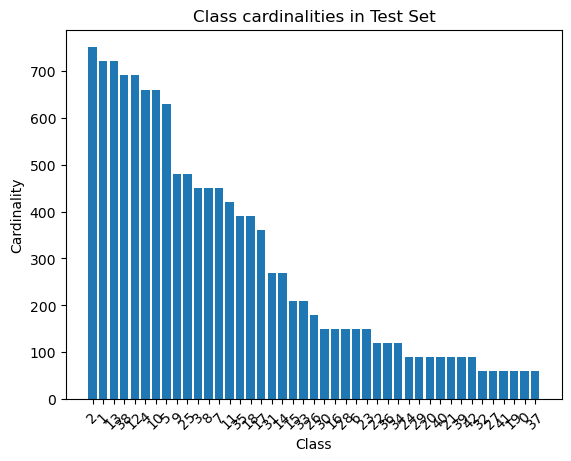

In [9]:
keys = [str(k) for k in test_set_countings_as_dict.keys()]
values = list(test_set_countings_as_dict.values())
plt.bar(keys, values)
plt.title("Class cardinalities in Test Set")
plt.xlabel('Class')
plt.ylabel('Cardinality')
plt.xticks(rotation=45)
plt.show()

**Test set seems a bit more imbalanced than training**<br>

By default **Pandas::Dataframe.value_counts()** returns a descending order dict (the opposite of what a did before).<br>
The **Imbalance Ratio** this time is bigger than 10; I think it could be evaluated as an imbalanced set <br>
<br>
This makes me a bit worried about what follows:

1. First of all if the **Test set** is not "compliant" with the **Training set**, I would be worried if the model will be able to learn the "true" distribution through empirical risk minimization;

2. Suppose I'd like to perform HyperParams Optimization (HPO), since the validation set is used in order to reduce the generalization error, if the test set in imbalance the risk would be to calibrate hyperparams over a non-representative validation set, but frankly this problem could be evaluated better by resampling all training, validation and test sets from the complete data (also: the given data do not mention any validation set).

<br>

**Good news**<br>
- what were defined as the **Highly Represented Classes** in the training set are still Highly Represented Classes in the test set (with some swaps). 
- The exact same thing can be said for the **Medium Represented Classes**. <br>
(by exclusions also for remaining)

I think that the best thing to do in this situation is to evaluate if the countings of the classes between the two sets are similar.

## 1.3) Evaluating class balanceness across sets

In [10]:
# are keys the same (hopefully yes)?
print(sorted(list(class_cardinalities.keys())) == sorted(list(test_set_countings_as_dict.keys()))) # YES

both_sets_cardinalities = dict()
# so now I can iterate through both dictionaries and collect, for each class (key in the dict), the number of occurrences in training and test set
for class_idx in list(class_cardinalities.keys()):
    print("Class {} | Training cardinality: {} | Test cardinality: {} ".format(class_idx, class_cardinalities[class_idx], test_set_countings_as_dict[class_idx]))
    # defining a tuple containing training card e testing card
    cardinality_tuple = (class_cardinalities[class_idx],   test_set_countings_as_dict[class_idx])
    both_sets_cardinalities[class_idx] = cardinality_tuple

True
Class 0 | Training cardinality: 150 | Test cardinality: 60 
Class 1 | Training cardinality: 1500 | Test cardinality: 720 
Class 2 | Training cardinality: 1500 | Test cardinality: 750 
Class 3 | Training cardinality: 960 | Test cardinality: 450 
Class 4 | Training cardinality: 1320 | Test cardinality: 660 
Class 5 | Training cardinality: 1260 | Test cardinality: 630 
Class 6 | Training cardinality: 300 | Test cardinality: 150 
Class 7 | Training cardinality: 960 | Test cardinality: 450 
Class 8 | Training cardinality: 960 | Test cardinality: 450 
Class 9 | Training cardinality: 990 | Test cardinality: 480 
Class 10 | Training cardinality: 1350 | Test cardinality: 660 
Class 11 | Training cardinality: 900 | Test cardinality: 420 
Class 12 | Training cardinality: 1410 | Test cardinality: 690 
Class 13 | Training cardinality: 1440 | Test cardinality: 720 
Class 14 | Training cardinality: 540 | Test cardinality: 270 
Class 15 | Training cardinality: 420 | Test cardinality: 210 
Class 1

In [11]:
both_sets_cardinalities

{0: (150, 60),
 1: (1500, 720),
 2: (1500, 750),
 3: (960, 450),
 4: (1320, 660),
 5: (1260, 630),
 6: (300, 150),
 7: (960, 450),
 8: (960, 450),
 9: (990, 480),
 10: (1350, 660),
 11: (900, 420),
 12: (1410, 690),
 13: (1440, 720),
 14: (540, 270),
 15: (420, 210),
 16: (300, 150),
 17: (750, 360),
 18: (810, 390),
 19: (150, 60),
 20: (240, 90),
 21: (240, 90),
 22: (270, 120),
 23: (360, 150),
 24: (180, 90),
 25: (1020, 480),
 26: (420, 180),
 27: (180, 60),
 28: (360, 150),
 29: (180, 90),
 30: (300, 150),
 31: (540, 270),
 32: (180, 60),
 33: (480, 210),
 34: (300, 120),
 35: (810, 390),
 36: (270, 120),
 37: (150, 60),
 38: (1380, 690),
 39: (210, 90),
 40: (240, 90),
 41: (180, 60),
 42: (180, 90)}

### LLM USED HERE!
**Reason:** I'd like to plot a barplot in which for the same class will be reported the cardinality of the class itself both in the training set and in test set. <br>
**Model:** Gemini<br>
### Asked to Gemini the following question:
**Question:**
Gemini ho un dizionario fatto in questo modo:
{0: (150, 60), 1: (1500, 720), 2: (1500, 750), 3: (960, 450), 4: (1320, 660)...

Ogni chiave è l'indice di una classe, i valori sono delle tuple dove il primo elemento rappresenta la cardinalità della classe stessa nel training set ed il secondo la cardinalità nel test set, come posso fare un matplotlib barplot dove per ogni indice riporto entrambe le misurazioni magari con colori diversi? Voglio affiancare i barplot per uno stesso indice

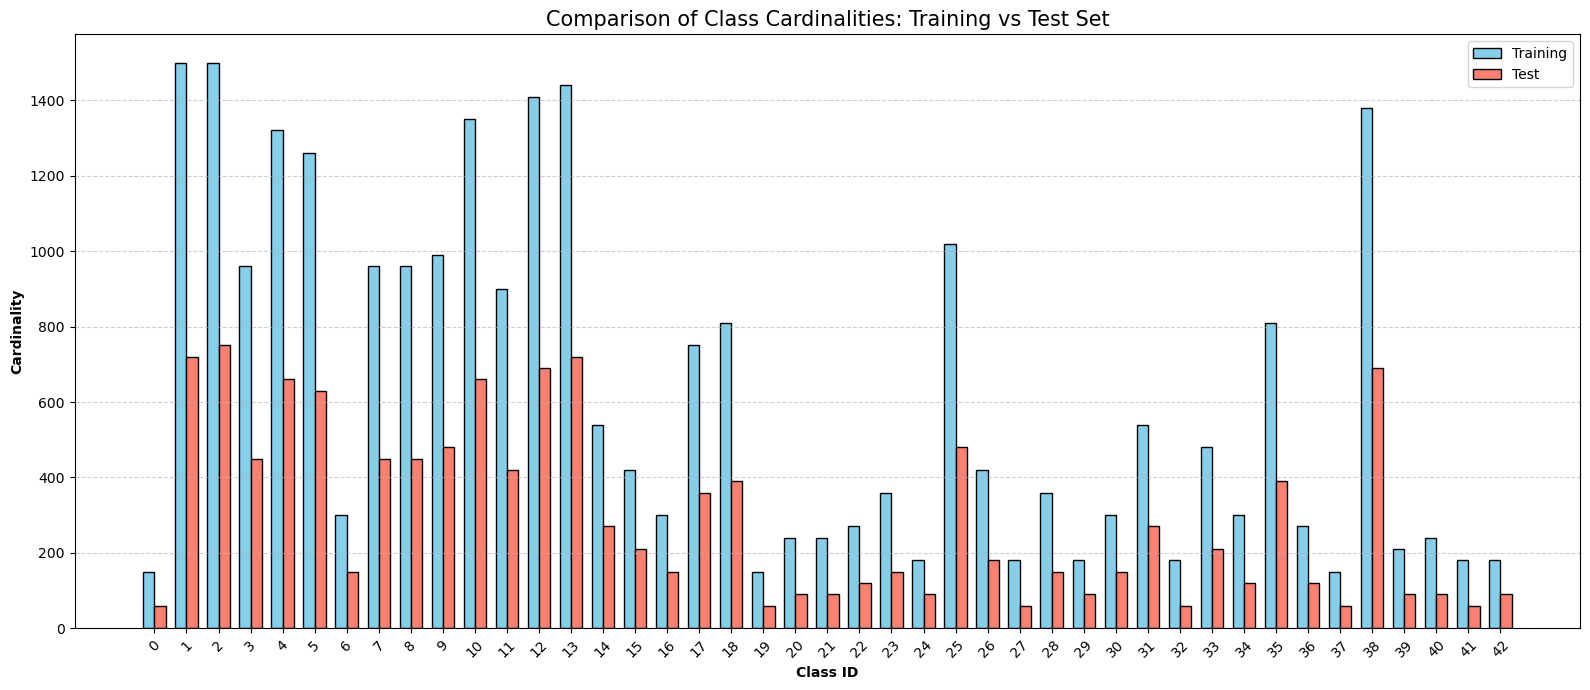

In [12]:
labels = list(both_sets_cardinalities.keys())
train_values = [v[0] for v in both_sets_cardinalities.values()]
test_values = [v[1] for v in both_sets_cardinalities.values()]

# Gemini
x = np.arange(len(labels)) 
width = 0.35                
fig, ax = plt.subplots(figsize=(16, 7))
rects1 = ax.bar(x - width/2, train_values, width, label='Training', color='skyblue', edgecolor='black')
rects2 = ax.bar(x + width/2, test_values, width, label='Test', color='salmon', edgecolor='black')
ax.set_xlabel('Class ID', fontweight='bold')
ax.set_ylabel('Cardinality', fontweight='bold')
ax.set_title('Comparison of Class Cardinalities: Training vs Test Set', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In general the number of occurrences of classes in training set and test set seems coherent. <br>

**Highly Represented Classes** (2,1,13,12,38,10,4,5) are coherently represented in both sets. Class 13 seems more represented than Class 12 on test set even though in the training set is the opposite (however I don't think that this will be quantitatively relevant).
This macro-set of classes is coherently represented, especially Classes 2,1 and 13 do not swap positions between training and test while class 38 swaps with class 12, the same for classes 4 and 5. <br>

**Medium Represented Classes** (25, 9, 8, 7, 3, 11, 35, 18, 17): Classes 25 and 9 swaps between training and test, the same for classes 8, 7, 11 (the latters for an irrelevant amount, while a bit higher amount for class 25 and 9) <br>

**Low Represented Classes** (remaining): seems coherent.

In [13]:
print(class_cardinalities)
print(test_set_countings_as_dict)

{0: 150, 1: 1500, 2: 1500, 3: 960, 4: 1320, 5: 1260, 6: 300, 7: 960, 8: 960, 9: 990, 10: 1350, 11: 900, 12: 1410, 13: 1440, 14: 540, 15: 420, 16: 300, 17: 750, 18: 810, 19: 150, 20: 240, 21: 240, 22: 270, 23: 360, 24: 180, 25: 1020, 26: 420, 27: 180, 28: 360, 29: 180, 30: 300, 31: 540, 32: 180, 33: 480, 34: 300, 35: 810, 36: 270, 37: 150, 38: 1380, 39: 210, 40: 240, 41: 180, 42: 180}
{2: 750, 1: 720, 13: 720, 38: 690, 12: 690, 4: 660, 10: 660, 5: 630, 9: 480, 25: 480, 3: 450, 8: 450, 7: 450, 11: 420, 35: 390, 18: 390, 17: 360, 31: 270, 14: 270, 15: 210, 33: 210, 26: 180, 30: 150, 16: 150, 28: 150, 6: 150, 23: 150, 22: 120, 36: 120, 34: 120, 24: 90, 29: 90, 20: 90, 40: 90, 21: 90, 39: 90, 42: 90, 32: 60, 27: 60, 41: 60, 19: 60, 0: 60, 37: 60}


I consider the code written until now useful in order to understand if third-party collected **and splitted** data are representative enough to does not led the future model to be too biased with respect to some observational data. Of course there will be an intristic bias due to the nature of the data, my goal here was to have a set of considerations ready for the future results evaluation. I wanted to be ready to make considerations such as: 
- *"the model seems to predict very well this class in the training set, but as an high error on the test set, has this class been well represented in the test set?"*<br>
- *"are we sure that the training set and the test set represent the same distribution?"*

Moving on to the image dimensions...

# 2) Data Visualization and Images shapes
This section the contains code relative to both data visualization and image shapes evaluations 

In [14]:
# Before I converted the images to tensors. Checking if it is possible to restore images without too much effort
training_images = GTSRB('_data/', split = "train", download=False) # just removed transformation and download
print("Training set contains {} images.".format(len(training_images)))
training_images[0][0]

Training set contains 26640 images.


Test set contains 12630 images.


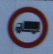

In [15]:
test_images = GTSRB('_data/', split = "test", download=False)
print("Test set contains {} images.".format(len(test_images)))
test_images[0][0]

## 2.1) Visualizing images

In [16]:
# Defining a function that given data and a number of images to plot does it by randomly choose
def plot_random_images(data, images_num: int, permute: bool = False):
    random_indices = np.random.choice(range(len(data)), images_num)
    indexed_images = [data[i] for i in random_indices]
    plt.figure(figsize=(25,20))
    for (i, (img, cls)) in enumerate(indexed_images):
        plt.subplot(10,10,i+1)
        if not permute:
            plt.imshow(img)
        else:
            plt.imshow(img.permute(1,2,0))
        plt.title("Class: {}".format(cls))
        plt.axis("off")

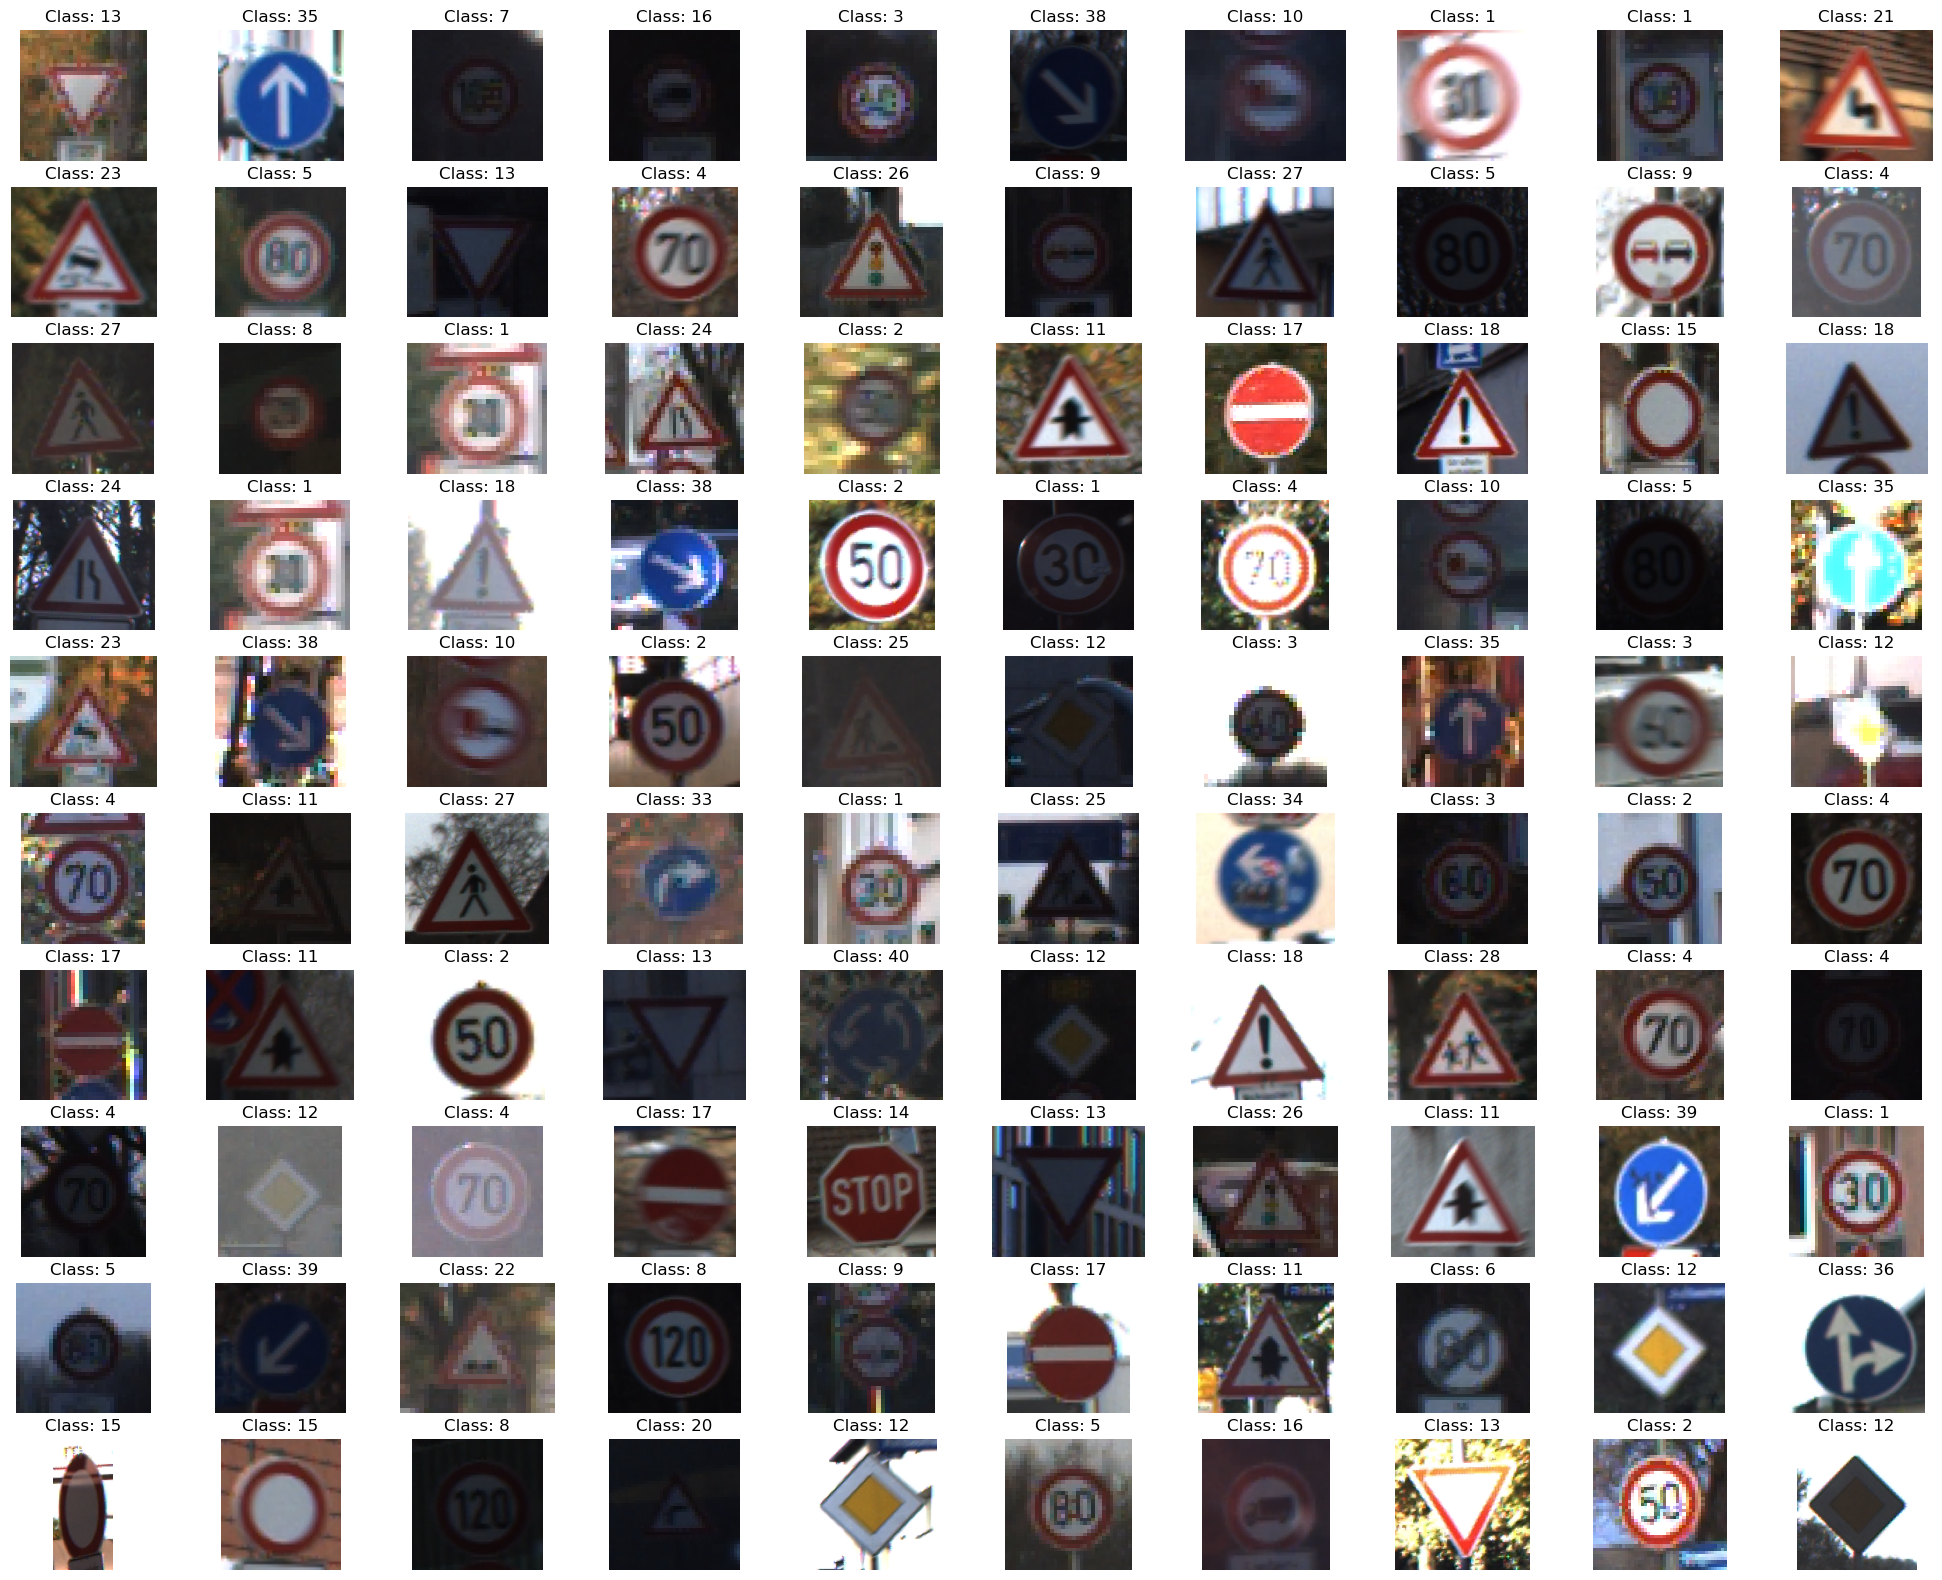

In [17]:
# plotting 100 random images from training set
plot_random_images(training_images, 100)

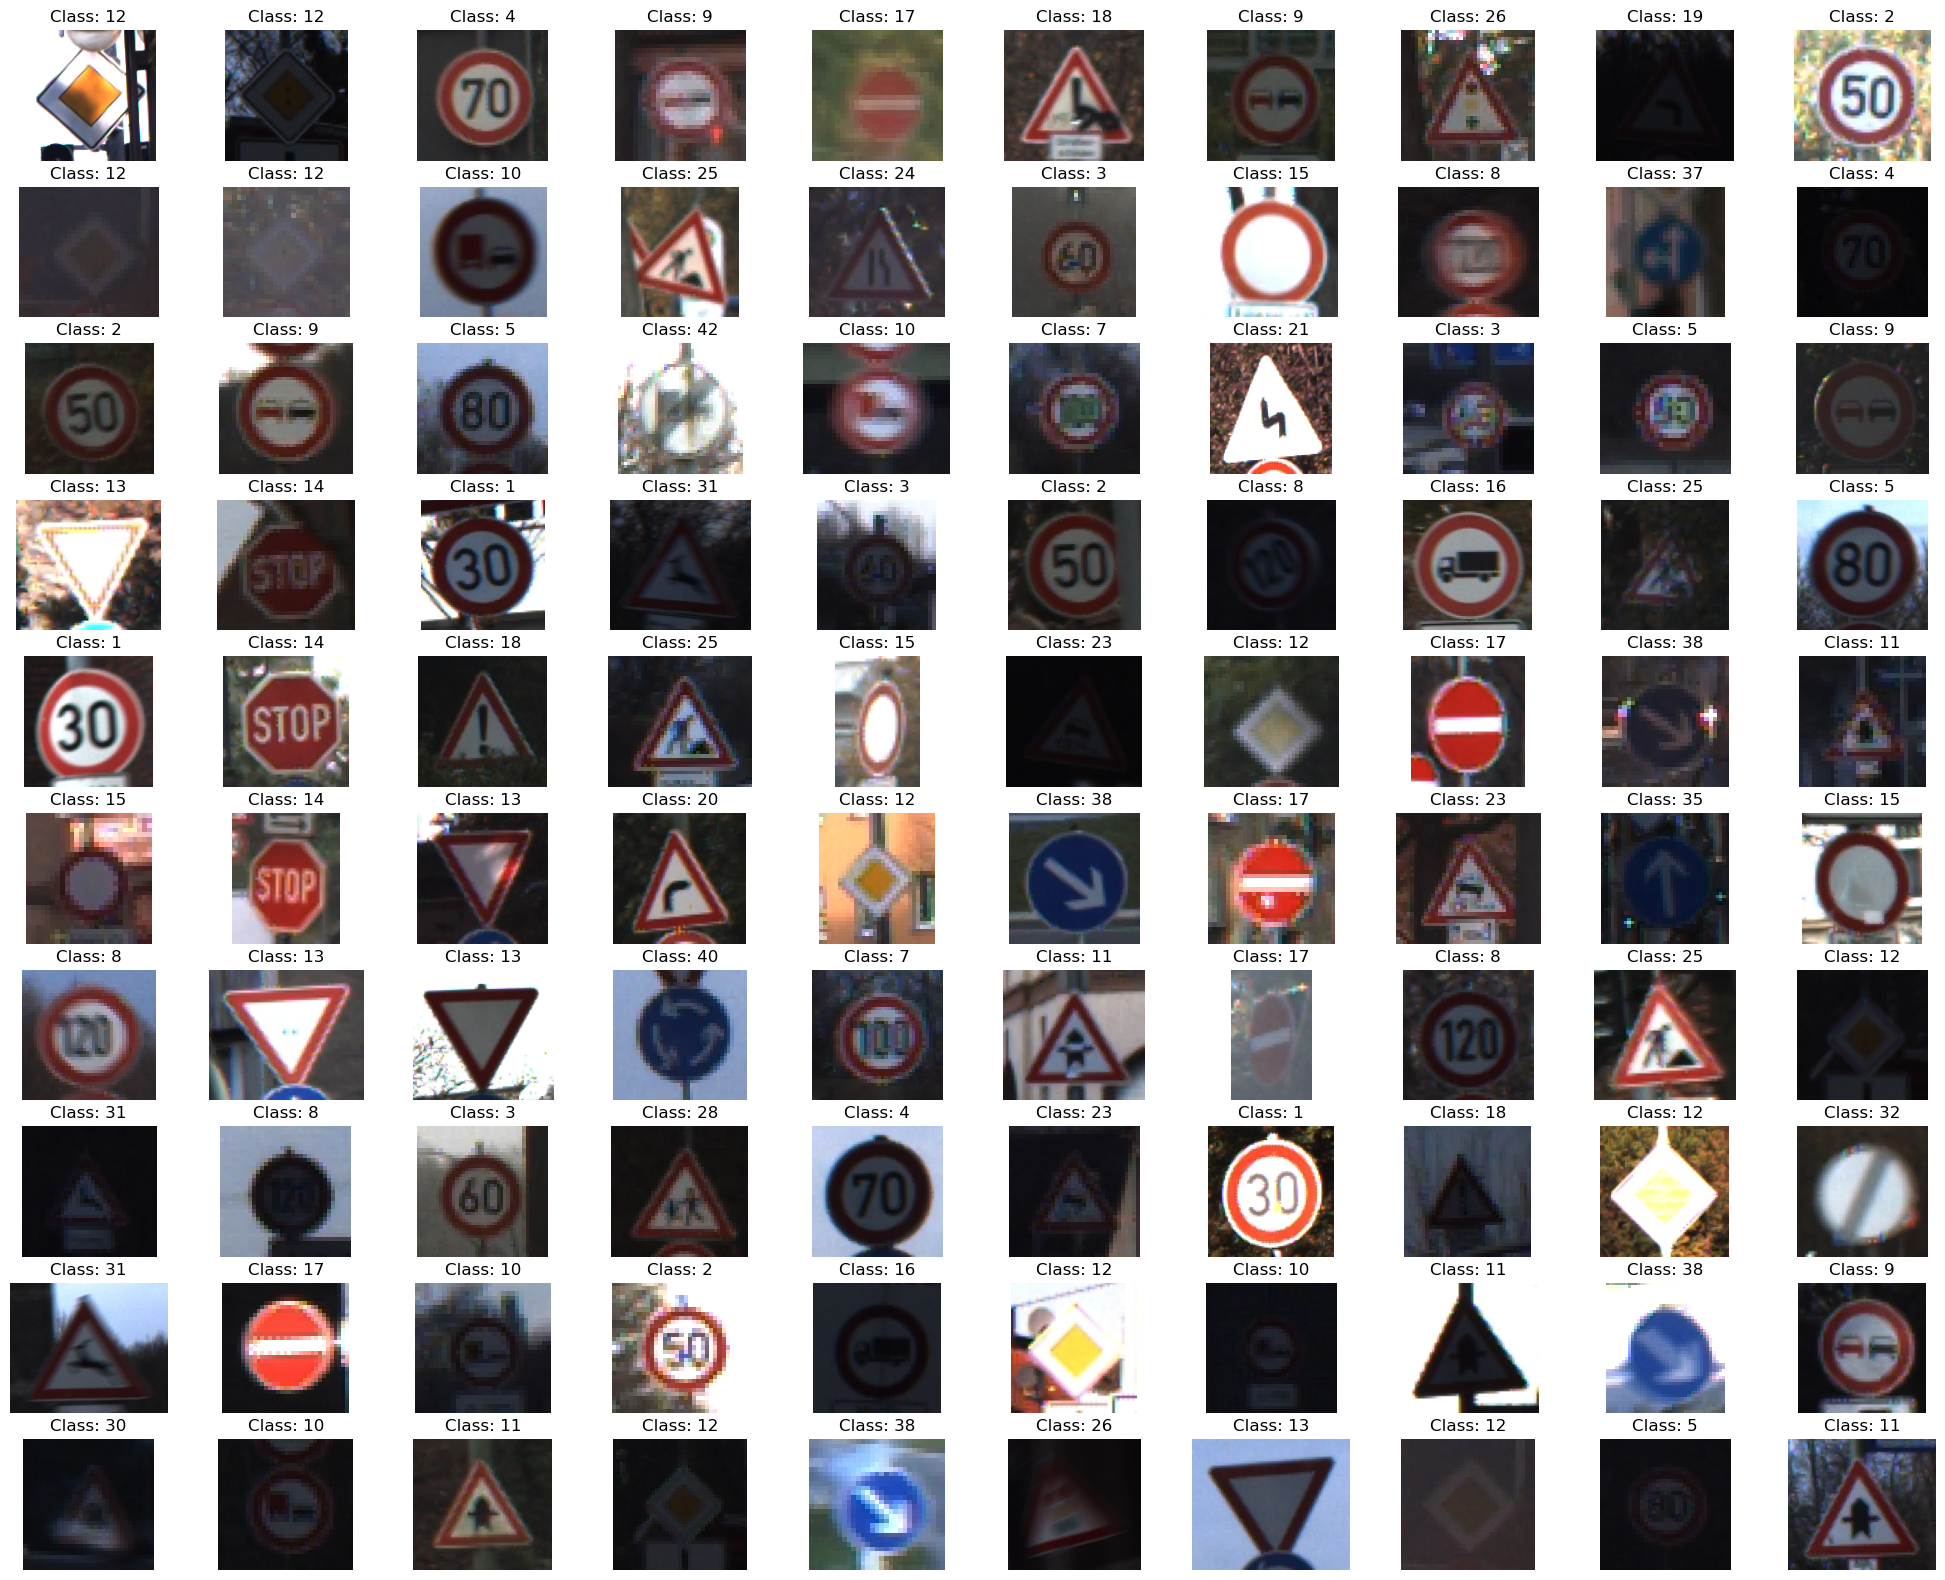

In [18]:
# plotting 100 random images from training set
plot_random_images(test_images, 100)

## 2.2) Taking a look at the shapes

In [19]:
# In order to investigate shapes, previous datasets (those as tensor) are taken in consideration.
training_data[0][0].shape

torch.Size([3, 30, 29])

Images shapes are (Channels, Height, Width)<br>
It would be interesting to understand if heights and widths vary accrosso multiple images.

In [20]:
def collect_images_dimensions(data):
    imgs_heights = list()
    imgs_widths = list()
    for i in range(len(data)):
        imgs_heights.append(data[i][0].shape[1])
        imgs_widths.append(data[i][0].shape[2])
    return imgs_heights, imgs_widths

In [21]:
training_imgs_heights, training_imgs_widths = collect_images_dimensions(training_data)

Some statistics about training heights and widths:

In [22]:
Q1_HEIGHTS_TRAIN = np.percentile(training_imgs_heights, 25)
MEDIAN_HEIGHTS_TRAIN = np.median(training_imgs_heights)
Q3_HEIGHTS_TRAIN = np.percentile(training_imgs_heights, 75)

Q1_WIDTHS_TRAIN = np.percentile(training_imgs_widths, 25)
MEDIAN_WIDTHS_TRAIN = np.median(training_imgs_widths)
Q3_WIDTHS_TRAIN = np.percentile(training_imgs_widths, 75)

print("25perc of the images has a height leq {} px; a width leq {}".format(Q1_HEIGHTS_TRAIN, Q1_WIDTHS_TRAIN))
print("50perc of the images has a height leq {} px; a width leq {}".format(MEDIAN_HEIGHTS_TRAIN, MEDIAN_WIDTHS_TRAIN))
print("75perc of the images has a height leq {} px; a width leq {}".format(Q3_HEIGHTS_TRAIN, Q3_WIDTHS_TRAIN))

25perc of the images has a height leq 35.0 px; a width leq 35.0
50perc of the images has a height leq 43.0 px; a width leq 43.0
75perc of the images has a height leq 58.0 px; a width leq 58.0


In [23]:
# Same for test set
test_imgs_heights, test_imgs_widths = collect_images_dimensions(test_data)

In [24]:
Q1_HEIGHTS_TEST = np.percentile(test_imgs_heights, 25)
MEDIAN_HEIGHTS_TEST = np.median(test_imgs_heights)
Q3_HEIGHTS_TEST = np.percentile(test_imgs_heights, 75)

Q1_WIDTHS_TEST = np.percentile(test_imgs_widths, 25)
MEDIAN_WIDTHS_TEST = np.median(test_imgs_widths)
Q3_WIDTHS_TEST = np.percentile(test_imgs_widths, 75)

print("25perc of the images has a height leq {} px; a width leq {}".format(Q1_HEIGHTS_TEST, Q1_WIDTHS_TEST))
print("50perc of the images has a height leq {} px; a width leq {}".format(MEDIAN_HEIGHTS_TEST, MEDIAN_WIDTHS_TEST))
print("75perc of the images has a height leq {} px; a width leq {}".format(Q3_HEIGHTS_TEST, Q3_WIDTHS_TEST))

25perc of the images has a height leq 35.0 px; a width leq 34.0
50perc of the images has a height leq 43.0 px; a width leq 43.0
75perc of the images has a height leq 57.0 px; a width leq 58.0


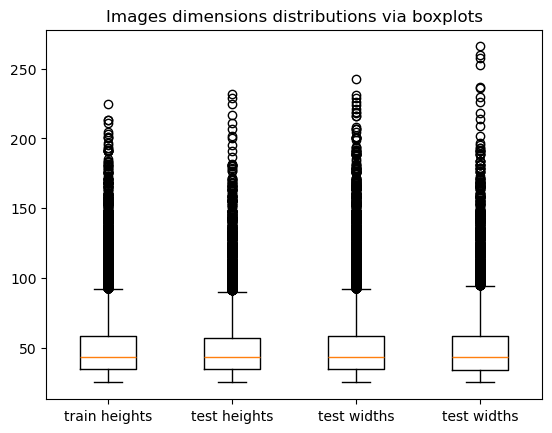

In [25]:
plt.title("Images dimensions distributions via boxplots")
plt.boxplot([training_imgs_heights, test_imgs_heights, training_imgs_widths, test_imgs_widths], 
            tick_labels=["train heights", "test heights", "test widths", "test widths"], vert=True)
plt.show()

**[TBC.2]** As the boxplots shows there is a non-negligible presence of outliers both in training set and test set and in both dimensions...

In [26]:
print("IQR_HEIGHTS IN TRAINING: {}".format(Q3_HEIGHTS_TRAIN - Q1_HEIGHTS_TRAIN))
print("IQR_WIDTHS IN TRAINING: {}".format(Q3_WIDTHS_TRAIN - Q1_WIDTHS_TRAIN))

IQR_HEIGHTS IN TRAINING: 23.0
IQR_WIDTHS IN TRAINING: 23.0


In [27]:
print("IQR_HEIGHTS IN TEST: {}".format(Q3_HEIGHTS_TEST - Q1_HEIGHTS_TEST))
print("IQR_WIDTHS IN TEST: {}".format(Q3_WIDTHS_TEST - Q1_WIDTHS_TEST))

IQR_HEIGHTS IN TEST: 22.0
IQR_WIDTHS IN TEST: 24.0


**TRAINING SET**
The previous results shows us that there is a variability of 23 pixels both in heights and widths in the training set.<br>
This means that not all images are equal in shapes, but that their variability (at least in the central range) is the same in both dimensions.

**TEST SET**
Also the test set presents images of different shapes.<br>
Their variability (at least in the central range) is the not the same, but is very similar (2px). <br>

So the **TEST SET** seems to be a good representer for the training set.

### Isolating outliers
Next step is to identifying the outliers both in Height and Width and for both training set and test set.<br>
<br>
As reported in [Matplotlib::boxplot Documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html):
> The whiskers extend from the box to the farthest data point lying within 1.5x the inter-quartile range (IQR) from the box. Flier points are those past the end of the whiskers. 
<br>

Boxplots previously plotted show only upper flier points, so we need to deal only with those.

In [ ]:
# Training set outliers
def compute_upper_whisker(q3, iqr):
    upper_whisker = q3 + 1.5 * iqr
    return upper_whisker

# Upper whisker for train heights
IQR_TRAIN_HEIGHTS = Q3_HEIGHTS_TRAIN - Q1_HEIGHTS_TRAIN
UPPER_WHISKER_TH = compute_upper_whisker(Q3_HEIGHTS_TRAIN, IQR_TRAIN_HEIGHTS)
outliers_heights_training = [h_train for h_train in training_imgs_heights if h_train > UPPER_WHISKER_TH]
# print("outliers heights in training set: {}".format(outliers_heights_training)) # removed to avoid notebook spam

# Upper whisker for train widths
IQR_TRAIN_WIDTHS = Q3_WIDTHS_TRAIN - Q1_WIDTHS_TRAIN
UPPER_WHISKER_TW = compute_upper_whisker(Q3_WIDTHS_TRAIN, IQR_TRAIN_WIDTHS)
outliers_widths_training = [w_train for w_train in training_imgs_widths if w_train > UPPER_WHISKER_TW]
# print("outliers widths in training set: {}".format(outliers_widths_training)) # removed to avoid notebook spam

# Test set outliers
# Upper whisker for test heights
IQR_TEST_HEIGHTS = Q3_HEIGHTS_TEST - Q1_HEIGHTS_TEST
UPPER_WHISKER_TESTH = compute_upper_whisker(Q3_HEIGHTS_TEST, IQR_TEST_HEIGHTS)
outliers_heights_test = [h_test for h_test in test_imgs_heights if h_test > UPPER_WHISKER_TESTH]
# print("outliers heights in test set: {}".format(outliers_heights_test)) # removed to avoid notebook spam

# Upper whisker for test widths
IQR_TEST_WIDTHS = Q3_WIDTHS_TEST - Q1_WIDTHS_TEST
UPPER_WHISKER_TESTW = compute_upper_whisker(Q3_WIDTHS_TEST, IQR_TEST_WIDTHS)
outliers_widths_test = [w_test for w_test in test_imgs_widths if w_test > UPPER_WHISKER_TESTW]
# print("outliers widths in test set: {}".format(outliers_widths_test)) # removed to avoid notebook spam


outliers heights in training set: [97, 110, 127, 148, 95, 108, 124, 93, 104, 93, 96, 100, 106, 110, 94, 96, 104, 107, 110, 118, 98, 117, 141, 170, 95, 101, 108, 117, 123, 135, 148, 96, 98, 104, 110, 107, 124, 97, 109, 93, 105, 100, 120, 144, 98, 94, 104, 93, 97, 103, 108, 114, 121, 129, 100, 112, 132, 93, 95, 100, 106, 108, 112, 118, 95, 99, 111, 131, 157, 98, 109, 131, 155, 98, 108, 117, 134, 99, 106, 96, 108, 120, 135, 98, 113, 135, 98, 104, 96, 100, 108, 116, 100, 117, 128, 104, 117, 98, 106, 121, 97, 109, 105, 110, 118, 94, 104, 112, 123, 97, 111, 93, 107, 130, 97, 111, 97, 105, 100, 116, 136, 99, 108, 115, 124, 134, 144, 96, 112, 93, 96, 104, 117, 123, 136, 93, 110, 129, 93, 95, 99, 108, 113, 122, 129, 144, 96, 110, 131, 97, 110, 95, 117, 97, 117, 99, 96, 103, 111, 106, 97, 100, 109, 104, 117, 99, 96, 100, 95, 107, 131, 105, 130, 155, 105, 121, 98, 94, 100, 112, 119, 95, 107, 123, 97, 113, 96, 107, 133, 106, 121, 95, 107, 101, 96, 100, 103, 111, 124, 129, 141, 96, 100, 106, 106, 1

# 3) Handling different shapes
Dealing with images of different shapes

In [29]:
# The "final" transform
transform = T.Compose([T.Resize(70), T.RandomCrop((64,64)), T.ToTensor(), T.Normalize(mean = [0.485, 0.456, 0.406], std=[0.229,0.224, 0.225])])
ds_train = GTSRB('_data/', split='train', transform=transform, download=True)
ds_test = GTSRB('_data/', split='test', transform=transform, download=True)

/Users/edoardocanti/opt/anaconda3/envs/DLA2026/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


[torchvision.transforms.v2::T.Resize()](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.v2.Resize.html#torchvision.transforms.v2.Resize) Resizes the input to the argument shape, seems a very "hard" transformation. *Is going to tranform every image into an image with smaller dims 70x70*.

[torchvision.transforms.v2::T.RandomCrop()](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.v2.RandomCrop.html#torchvision.transforms.v2.RandomCrop) Crops the input at a random location. *Is going to transform each of the previous image into a 64x64 by randomly cropping the input image itself. Seems very arbitrary, but actually all images are very "centered" wrt the target, so the randomicity of the crop, given the outputsize is not that hard* (it would be harder given a too smaller dimension wrt the input dimension).

[torchvision.transforms.v2::T.Normalize()](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.v2.Normalize.html#torchvision.transforms.v2.Normalize) Normalizes wrt given mean and standard deviation, since images are [C, H, W] dimension, there will be 3 means and 3 stadevs.

In [30]:
example_training_image = training_images[0][0]
example_training_image

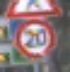

In [31]:
resize = T.Resize(70)
resized_training_image = resize(example_training_image)
resized_training_image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.370448..0.025620991].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6897851..1.5071026].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7582842..0.19991292].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781574..0.5833553].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5870366..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6041614..1.1585187].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..

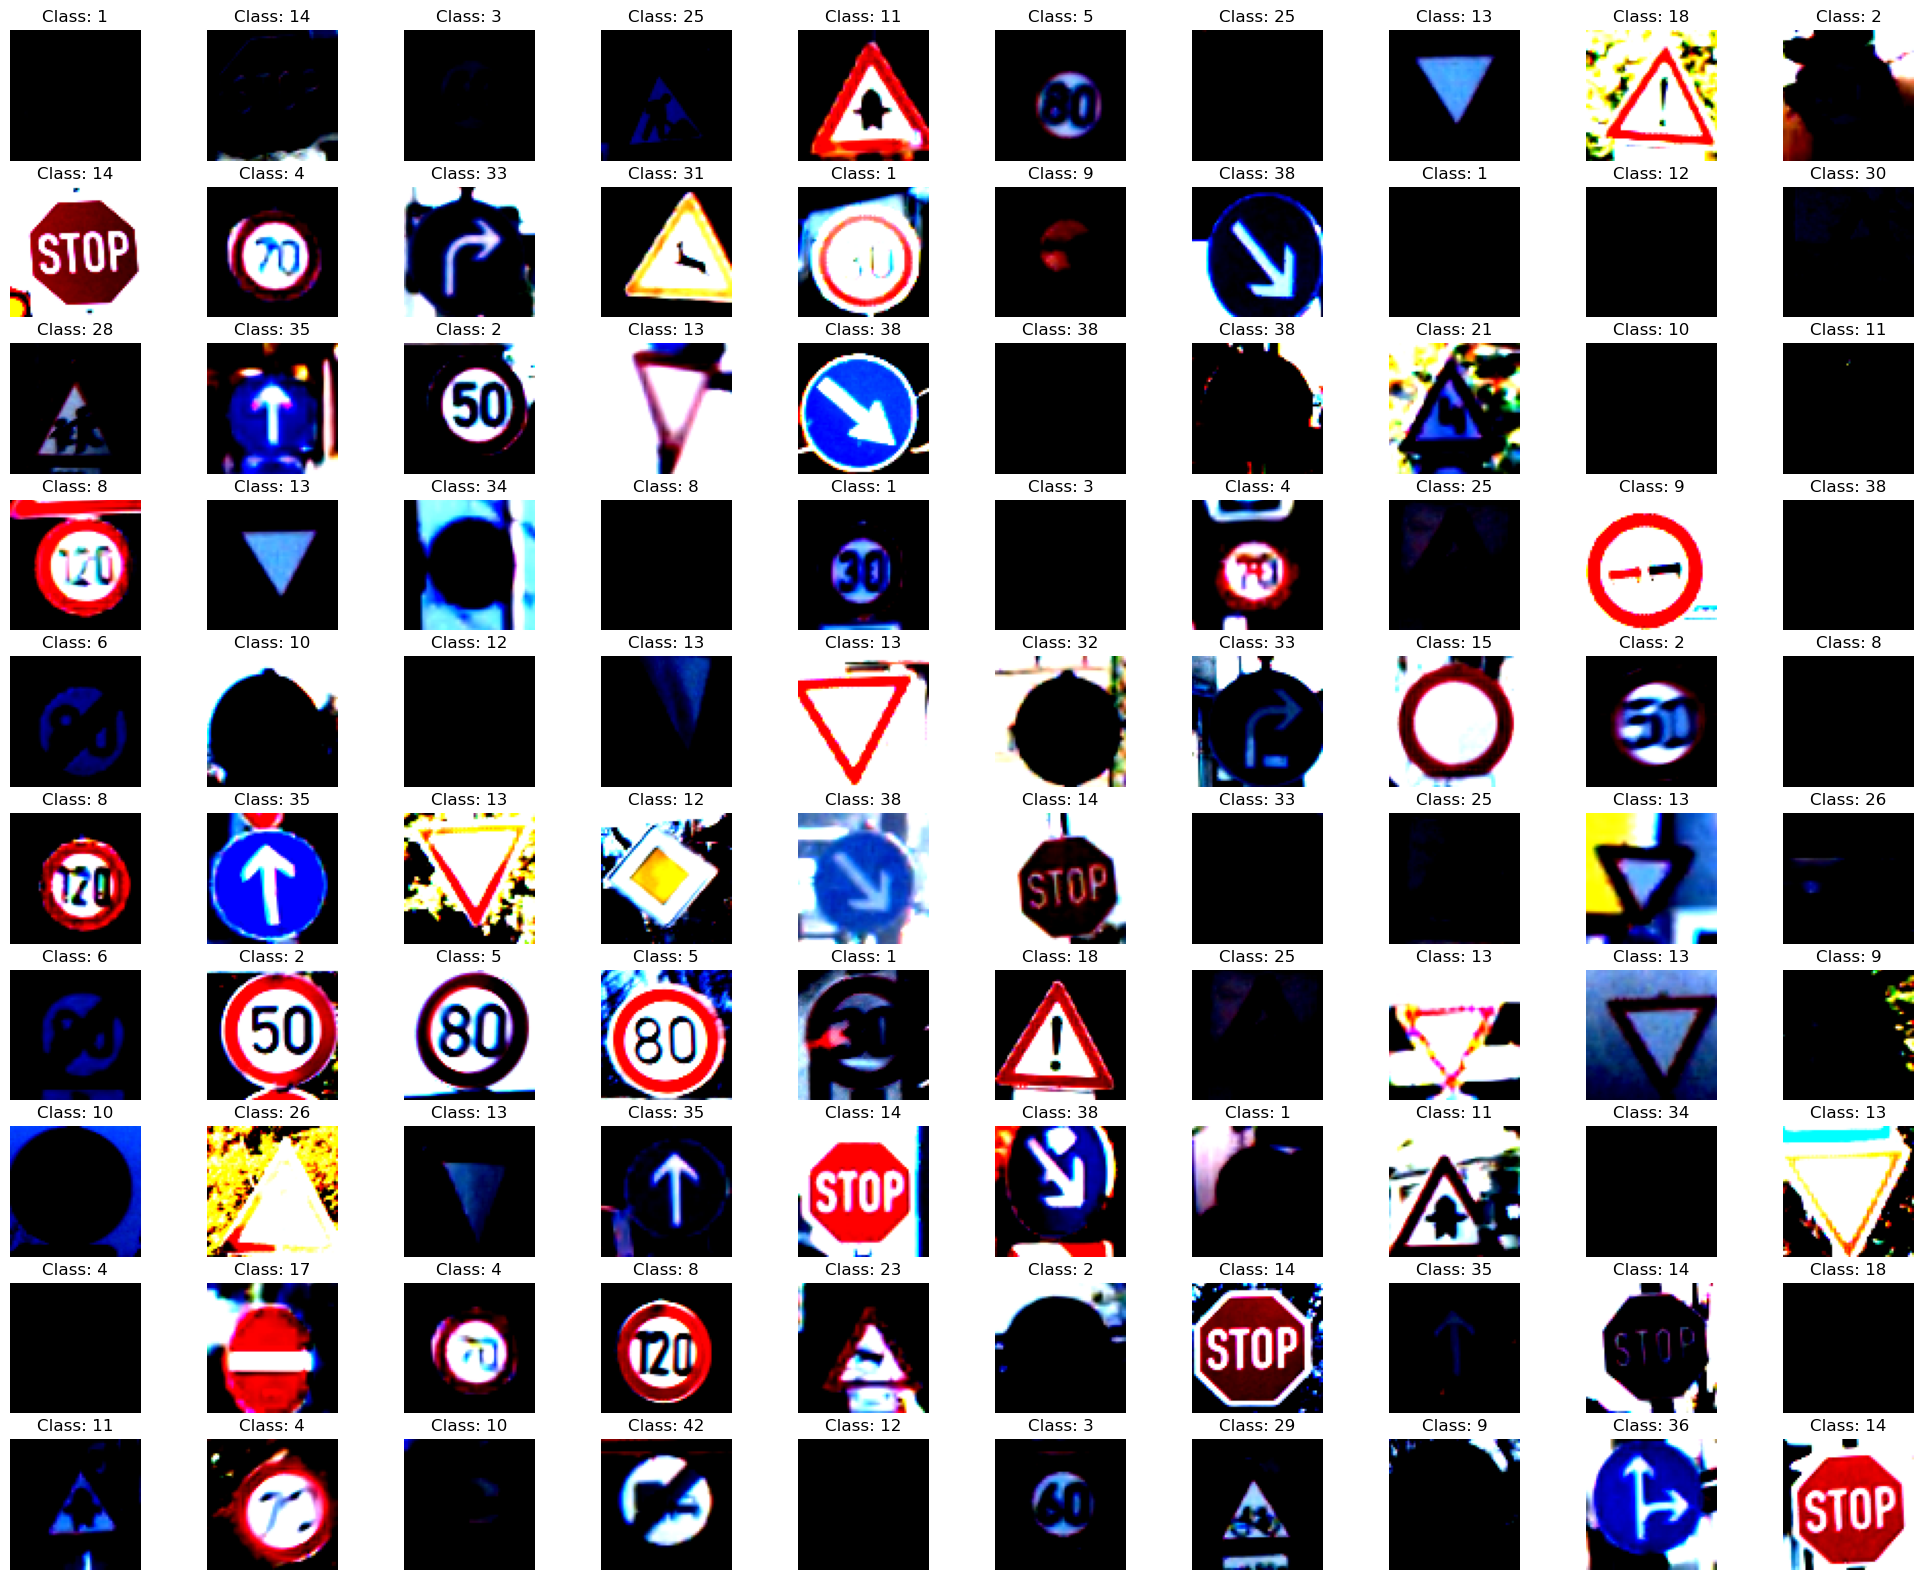

In [32]:
# Visualizing transformed images:
plot_random_images(ds_train, 100, permute = True)

# Analysis

As shown in **Section 1**:
1. (**Section 1**) Training Set and Test set cannot be treated (for the moment) as imbalanced.
2. (**Section 1**) **[TBC.1]** Refers to the fact that data can be splitted into 3 *"macro-classes"* Highly Represented, Medium and Low. 
3. (**Section 1**) Since the **[TBC.1]** *"macro-classes"* composition is coherent between training and test set I would expect a model to better perform on Highly Represented classes, a bit worst on Medium, and definitely worst on Low, since the predictive performance of the model will be driven by the data composition.
4. (**Section 2** ) Regarding **[TBC.2]** the *"non-negligible presence of outliers"* we could say that the applied Transformation in **Section 3** is going to solve the problem, also by considering that the random crop size (for the given data!) does not introduce the risk of loosing the core information. **By the way it would be interesting to understand if different tansformation would led to different performances**.